In [21]:
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage
from langchain_ollama import ChatOllama

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [22]:
store = InMemoryStore()

user_id = "u1"

# Store user details as a single blob (simple for teaching)
# You can also split into multiple records; this keeps it easy.
user_details = ("user", user_id, "details")

store.put(user_details, "profile_1", {"data": "Name: Abhinav"})
store.put(user_details, "profile_2", {"data": "Profession: Teaches AI on YouTube"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "Building MCP servers (Python-based project)"})

In [23]:
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [24]:
llm = ChatOllama(model="llama3")

In [25]:
def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    
    user_id = config["configurable"]["user_id"]

    # Read-only: fetch user details memory (no writes)
    user_details = ("user", user_id, "details")
    items = store.search(user_details)

    # Convert memory items into a string blob for {user_details_content}
    # Keep it dead simple for teaching.
    if items:
        user_details_content = "\n".join(f"- {it.value.get('data', '')}" for it in items)
    else:
        user_details_content = ""  # prompt says it may be empty

    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        user_details_content=user_details_content
    )

    system_msg = SystemMessage(content=system_prompt)

    response = llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

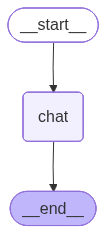

In [26]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [27]:
config = {'configurable': {"user_id": 'u1'}}
result = graph.invoke(
    {'messages' : {'role': 'user', 'content' : 'Explain gen ai in simple terms.'}},
    config=config
)


In [28]:
print(result['messages'][-1].content)

Hey Abhinav, let's talk about Generalized Artificial Intelligence or Gen AI for short.

As you know, your expertise lies in teaching AI on YouTube, so I'll try to break it down in a way that's easy to understand. Imagine a super smart robot that can learn from any data, not just specific rules or patterns like traditional AI systems do. This robot, or rather, this Gen AI is designed to tackle complex tasks and make decisions like humans do.

To simplify it further, think of Gen AI like a master chef who can adapt recipes based on various ingredients and cooking styles. In the same way, Gen AI can adapt to different situations and problems by learning from vast amounts of data and experience.

In your MCP servers project, you might be interested in how Gen AI can help with tasks such as:

1. Predictive maintenance: Using machine learning algorithms to forecast equipment failures and perform proactive maintenance.
2. Real-time monitoring: Monitoring system performance and detecting anoma

In [ ]:
# STORING THE MEMORY FROM THE CURRENT CONVERSATION
from pydantic import BaseModel, Field
from typing import List
import uuid

store = InMemoryStore()
extractor = ChatOllama(model="llama3")


In [30]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memory")
    memories: List[str] = Field(default_factory=list, description="Atomic user memories to store.")

mem_extractor = extractor.with_structured_output(MemoryDecision)

In [31]:
def remember_only_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    namespace = ("user", user_id, "details")
    last_msg = state["messages"][-1].content

    decision: MemoryDecision = mem_extractor.invoke(
        [
            SystemMessage(content=(
            "Extract LONG-TERM memories from the user's response.\n"
            "Only store stable, user-specific info.\n"
            "Do NOT store transient info.\n"
            "Return should_write=false if nothing is worth storing.\n"
            "Each memory should be a short atomic sentence."
            )),
            {'role' : 'user', 'content' : last_msg}
        ]
    )
    if decision.should_write:
        for mem in decision.memories:
            store.put(namespace, str(uuid.uuid4()), {"data": mem})
    return {"messages" : [{"role": "assistant", "content": "Memories updated."}]}


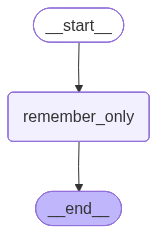

In [32]:
builder = StateGraph(MessagesState)
builder.add_node("remember_only", remember_only_node)
builder.add_edge(START, "remember_only")
builder.add_edge("remember_only", END)
graph = builder.compile(store=store)
graph

In [41]:
config = {'configurable': {"user_id": 'u1'}}
result = graph.invoke(
    {'messages' : {'role': 'user', 'content' : 'Hello, my name is Abhinav.'}},
    config=config
)
result = graph.invoke(
    {'messages' : {'role': 'user', 'content' : 'I play cricket as a professiona.'}},
    config=config
)
result = graph.invoke(
    {'messages' : {'role': 'user', 'content' : 'I am 23 years old.'}},
    config=config
)


In [39]:
result['messages'][-1]


AIMessage(content='Memories updated.', additional_kwargs={}, response_metadata={}, id='6ef09660-dd30-4fb9-98ee-f7bfdeaa045b', tool_calls=[], invalid_tool_calls=[])

In [42]:
items = store.search(("user", "u1", "details"))
for item in items:
    print(item.value['data'])

I am a professional cricketer.
